In [2]:
import sys, torch
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

import transformers, mmseg
print(f"transformers : {transformers.__version__}")
print(f"mmsegmentation : {mmseg.__version__}")

Python : 3.10.20
PyTorch : 2.1.0+cu118
GPU : NVIDIA GeForce RTX 2060
VRAM : 6.4 Go
transformers : 4.36.2
mmsegmentation : 1.2.2


In [6]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "benchmark_final_4models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR = PROJECT_ROOT / "data" / "raw" / "dalby"
PERSP_DIR = IMAGES_DIR / "persp"


print(f"Outputs : {OUTPUT_DIR}")

Outputs : C:\Users\youss\Downloads\coolpath_local\data\outputs\benchmark_final_4models


In [8]:
image_files = sorted(PERSP_DIR.glob("dalby_*.jpg"))

## Configuration 

In [21]:
hr18_src = Path(r"C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\.mim\configs\hrnet\fcn_hr18_4xb2-160k_cityscapes-512x1024.py")

hrnet_cfg_path = CHECKPOINTS_DIR / "fcn_hr48_4xb2-160k_cityscapes-512x1024.py"

hrnet_cfg_content = f"""
_base_ = r'{hr18_src.as_posix()}'

model = dict(
    pretrained='open-mmlab://msra/hrnetv2_w48',
    backbone=dict(
        extra=dict(
            stage2=dict(num_channels=(48, 96)),
            stage3=dict(num_channels=(48, 96, 192)),
            stage4=dict(num_channels=(48, 96, 192, 384))
        )
    ),
    decode_head=dict(
        in_channels=[48, 96, 192, 384],
        channels=sum([48, 96, 192, 384])
    )
)
"""

hrnet_cfg_path.write_text(hrnet_cfg_content.strip(), encoding="utf-8")

print(hrnet_cfg_path.read_text(encoding="utf-8"))

_base_ = r'C:/Users/youss/miniconda3/envs/coolpath/lib/site-packages/mmseg/.mim/configs/hrnet/fcn_hr18_4xb2-160k_cityscapes-512x1024.py'

model = dict(
    pretrained='open-mmlab://msra/hrnetv2_w48',
    backbone=dict(
        extra=dict(
            stage2=dict(num_channels=(48, 96)),
            stage3=dict(num_channels=(48, 96, 192)),
            stage4=dict(num_channels=(48, 96, 192, 384))
        )
    ),
    decode_head=dict(
        in_channels=[48, 96, 192, 384],
        channels=sum([48, 96, 192, 384])
    )
)


In [22]:
patterns = {
    "SegFormer-B5 (1024x1024)": (
        "segformer_mit-b5_8xb1-160k_cityscapes-1024x1024",
        "segformer_mit-b5_*.pth",
        "1024x1024",
    ),
    "Mask2Former-SwinB (512x1024)": (
        "mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024",
        "mask2former_swin-b*.pth",
        "512x1024",
    ),
    "DeepLabV3+-R101 (512x1024)": (
        "deeplabv3plus_r101-d8_4xb2-80k_cityscapes-512x1024",
        "deeplabv3plus_r101-d8_*.pth",
        "512x1024",
    ),
    "HRNet-W48 (512x1024)": (
        "fcn_hr48_4xb2-160k_cityscapes-512x1024",
        "fcn_hr48_*.pth",
        "512x1024",
    ),
}

MMSEG_CONFIG = {}
for name, (config_basename, pth_pattern, crop) in patterns.items():
    config_path = CHECKPOINTS_DIR / f"{config_basename}.py"
    pth_files = list(CHECKPOINTS_DIR.glob(pth_pattern))
    if pth_files and config_path.exists():
        MMSEG_CONFIG[name] = {
            "config": config_path,
            "checkpoint": pth_files[0],
            "crop": crop,
        }
        print(f"  {name:<35s} OK  (crop {crop})")
    else:
        print(f"  {name:<35s} MANQUANT")

print(f"\n{len(MMSEG_CONFIG)}/{len(patterns)} modeles MMSeg prets")

  SegFormer-B5 (1024x1024)            OK  (crop 1024x1024)
  Mask2Former-SwinB (512x1024)        OK  (crop 512x1024)
  DeepLabV3+-R101 (512x1024)          OK  (crop 512x1024)
  HRNet-W48 (512x1024)                OK  (crop 512x1024)

4/4 modeles MMSeg prets


## Palette Cityscapes

In [15]:
import numpy as np
import matplotlib.pyplot as plt

CITYSCAPES_PALETTE = np.array([
    [128,  64, 128], [244,  35, 232], [ 70,  70,  70], [102, 102, 156], [190, 153, 153],
    [153, 153, 153], [250, 170,  30], [220, 220,   0], [107, 142,  35], [152, 251, 152],
    [ 70, 130, 180], [220,  20,  60], [255,   0,   0], [  0,   0, 142], [  0,   0,  70],
    [  0,  60, 100], [  0,  80, 100], [  0,   0, 230], [119,  11,  32],
], dtype=np.uint8)

CITYSCAPES_LABELS = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic_light",
    "traffic_sign", "vegetation", "terrain", "sky", "person", "rider",
    "car", "truck", "bus", "train", "motorcycle", "bicycle",
]


def colorize(mask):
    return CITYSCAPES_PALETTE[np.clip(mask, 0, 18)]


def overlay(image, mask, alpha=0.55):
    color = colorize(mask)
    img_arr = np.array(image.convert("RGB"))
    return ((1 - alpha) * img_arr + alpha * color).astype(np.uint8)

## Inférence MMSegmentation (B5 + Mask2Former + DeepLabV3+ + HRNet-W48)

In [23]:
from mmseg.apis import init_model, inference_model
from PIL import Image
import time


def run_mmseg_model(model_name, config_path, checkpoint_path, image_paths):
    print(f"\n{'=' * 65}")
    print(f"  {model_name}")
    print(f"{'=' * 65}")

    model = init_model(str(config_path), str(checkpoint_path), device="cuda:0")

    # Warmup
    _ = inference_model(model, str(image_paths[0]))
    torch.cuda.synchronize()

    masks = {}
    times = []
    print(f"  Inference sur {len(image_paths)} images...")
    t_start = time.perf_counter()

    for i, img_path in enumerate(image_paths, 1):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        result = inference_model(model, str(img_path))
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        times.append(elapsed)

        mask = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        masks[img_path.name] = mask

        if i % 5 == 0 or i == len(image_paths):
            elapsed_total = time.perf_counter() - t_start
            avg = elapsed_total / i
            eta = avg * (len(image_paths) - i)
            print(f"    [{i:>3}/{len(image_paths)}]  avg={avg*1000:6.0f}ms  ETA={eta:5.0f}s")

    del model
    torch.cuda.empty_cache()
    return masks, times


# Lancement des 3 modeles MMSeg
all_masks = {}
all_times = {}
all_crops = {}

for model_name, cfg in MMSEG_CONFIG.items():
    masks, times = run_mmseg_model(model_name, cfg["config"], cfg["checkpoint"], image_files)
    all_masks[model_name] = masks
    all_times[model_name] = times
    all_crops[model_name] = cfg["crop"]

print("\n=== Inference MMSeg terminee (3 modeles) ===")


  SegFormer-B5 (1024x1024)
Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\checkpoints\segformer_mit-b5_8x1_1024x1024_160k_cityscapes_20211206_072934-87a052ec.pth
  Inference sur 93 images...
    [  5/93]  avg=   939ms  ETA=   83s
    [ 10/93]  avg=   913ms  ETA=   76s
    [ 15/93]  avg=   906ms  ETA=   71s
    [ 20/93]  avg=   904ms  ETA=   66s
    [ 25/93]  avg=   902ms  ETA=   61s
    [ 30/93]  avg=   902ms  ETA=   57s
    [ 35/93]  avg=   902ms  ETA=   52s
    [ 40/93]  avg=   902ms  ETA=   48s
    [ 45/93]  avg=   903ms  ETA=   43s
    [ 50/93]  avg=   904ms  ETA=   39s
    [ 55/93]  avg=   904ms  ETA=   34s
    [ 60/93]  avg=   905ms  ETA=   30s
    [ 65/93]  avg=   906ms  ETA=   25s
    [ 70/93]  avg=   907ms  ETA=   21s
    [ 75/93]  avg=   908ms  ETA=   16s
    [ 80/93]  avg=   909ms  ETA=   12s
    [ 85/93]  avg=   910ms  ETA=    7s
    [ 90/93]  avg=   911ms  ETA=    3s
    [ 93/93]  avg=   912ms  ETA=    0s

  Mask2Former-SwinB (512x102

## Inférence SegFormer-B0 (HuggingFace, 512×1024)

In [24]:
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import torch.nn.functional as F


SEGFORMER_B0_NAME = "SegFormer-B0 (512x1024)"
HF_CHECKPOINT = "nvidia/segformer-b0-finetuned-cityscapes-512-1024"

print(f"=== {SEGFORMER_B0_NAME} ===")
print(f"Telechargement depuis HuggingFace : {HF_CHECKPOINT}")

segformer_b0 = SegformerForSemanticSegmentation.from_pretrained(HF_CHECKPOINT).to("cuda:0").eval()
segformer_b0_proc = SegformerImageProcessor.from_pretrained(HF_CHECKPOINT)

n_params = sum(p.numel() for p in segformer_b0.parameters())
print(f"Parametres : {n_params/1e6:.2f} M\n")


@torch.no_grad()
def predict_segformer_b0(image):
    inputs = segformer_b0_proc(images=image, return_tensors="pt").to("cuda:0")
    logits = segformer_b0(**inputs).logits
    upsampled = F.interpolate(
        logits, size=(image.size[1], image.size[0]),
        mode="bilinear", align_corners=False,
    )
    return upsampled.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)


# Warmup
img0 = Image.open(image_files[0]).convert("RGB")
_ = predict_segformer_b0(img0)
torch.cuda.synchronize()

# Inference
masks_b0 = {}
times_b0 = []
print(f"Inference sur {len(image_files)} images...")
t_start = time.perf_counter()

for i, img_path in enumerate(image_files, 1):
    image = Image.open(img_path).convert("RGB")
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    mask = predict_segformer_b0(image)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    times_b0.append(elapsed)
    masks_b0[img_path.name] = mask

    if i % 5 == 0 or i == len(image_files):
        elapsed_total = time.perf_counter() - t_start
        avg = elapsed_total / i
        eta = avg * (len(image_files) - i)
        print(f"  [{i:>3}/{len(image_files)}]  avg={avg*1000:6.0f}ms  ETA={eta:5.0f}s")

# Ajouter aux resultats
all_masks[SEGFORMER_B0_NAME] = masks_b0
all_times[SEGFORMER_B0_NAME] = times_b0
all_crops[SEGFORMER_B0_NAME] = "512x1024"

del segformer_b0
torch.cuda.empty_cache()
print("\n=== Inference SegFormer-B0 terminee ===")

=== SegFormer-B0 (512x1024) ===
Telechargement depuis HuggingFace : nvidia/segformer-b0-finetuned-cityscapes-512-1024


C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


Parametres : 3.72 M

Inference sur 93 images...
  [  5/93]  avg=   144ms  ETA=   13s
  [ 10/93]  avg=   149ms  ETA=   12s
  [ 15/93]  avg=   145ms  ETA=   11s
  [ 20/93]  avg=   144ms  ETA=   10s
  [ 25/93]  avg=   142ms  ETA=   10s
  [ 30/93]  avg=   142ms  ETA=    9s
  [ 35/93]  avg=   143ms  ETA=    8s
  [ 40/93]  avg=   144ms  ETA=    8s
  [ 45/93]  avg=   145ms  ETA=    7s
  [ 50/93]  avg=   146ms  ETA=    6s
  [ 55/93]  avg=   147ms  ETA=    6s
  [ 60/93]  avg=   148ms  ETA=    5s
  [ 65/93]  avg=   148ms  ETA=    4s
  [ 70/93]  avg=   149ms  ETA=    3s
  [ 75/93]  avg=   149ms  ETA=    3s
  [ 80/93]  avg=   149ms  ETA=    2s
  [ 85/93]  avg=   149ms  ETA=    1s
  [ 90/93]  avg=   149ms  ETA=    0s
  [ 93/93]  avg=   149ms  ETA=    0s

=== Inference SegFormer-B0 terminee ===


## Tableau récapitulatif 

In [25]:
rows = []
for model_name, times in all_times.items():
    crop = all_crops[model_name]
    for img_path, t in zip(image_files, times):
        rows.append({
            "model": model_name,
            "crop": crop,
            "image": img_path.name,
            "time_ms": t * 1000,
            "fps": 1.0 / t,
        })
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_DIR / "benchmark_detailed.csv", index=False)

summary = df.groupby(["model", "crop"]).agg(
    n_images=("image", "count"),
    time_mean_ms=("time_ms", "mean"),
    time_std_ms=("time_ms", "std"),
    fps_mean=("fps", "mean"),
).round(2)
summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv")
print("Resume :")
summary

Resume :


,,n_images,time_mean_ms,time_std_ms,fps_mean
model,crop,,,,
DeepLabV3+-R101 (512x1024),512x1024,93,848.62,15.70,1.18
HRNet-W48 (512x1024),512x1024,93,471.92,24.31,2.12
Mask2Former-SwinB (512x1024),512x1024,93,736.81,11.39,1.36
SegFormer-B0 (512x1024),512x1024,93,102.89,8.65,9.79
SegFormer-B5 (1024x1024),1024x1024,93,904.55,24.94,1.11


## Distribution des classes par modèle

In [26]:
def class_distribution(masks_dict):
    counts = np.zeros(19, dtype=np.int64)
    total = 0
    for mask in masks_dict.values():
        for c in range(19):
            counts[c] += (mask == c).sum()
        total += mask.size
    return counts / total


distrib = {name: class_distribution(masks) for name, masks in all_masks.items()}
distrib_df = pd.DataFrame(distrib, index=CITYSCAPES_LABELS)
distrib_df = distrib_df.sort_values(by=list(distrib.keys())[0], ascending=False)
distrib_df.to_csv(OUTPUT_DIR / "class_distribution.csv")
print("Proportion de pixels par classe (moyenne) :\n")
print((distrib_df * 100).round(2).to_string())

Proportion de pixels par classe (moyenne) :

               SegFormer-B5 (1024x1024)  Mask2Former-SwinB (512x1024)  DeepLabV3+-R101 (512x1024)  HRNet-W48 (512x1024)  SegFormer-B0 (512x1024)
road                              28.56                         24.37                       21.91                 22.37                    25.88
sky                               22.92                         22.95                       22.19                 22.32                    22.17
building                          17.75                         16.74                       22.82                 19.64                    19.03
vegetation                        10.59                         10.40                       13.43                 15.06                    10.51
wall                               5.71                          9.66                        5.03                  1.58                     8.38
terrain                            3.99                          3.97                

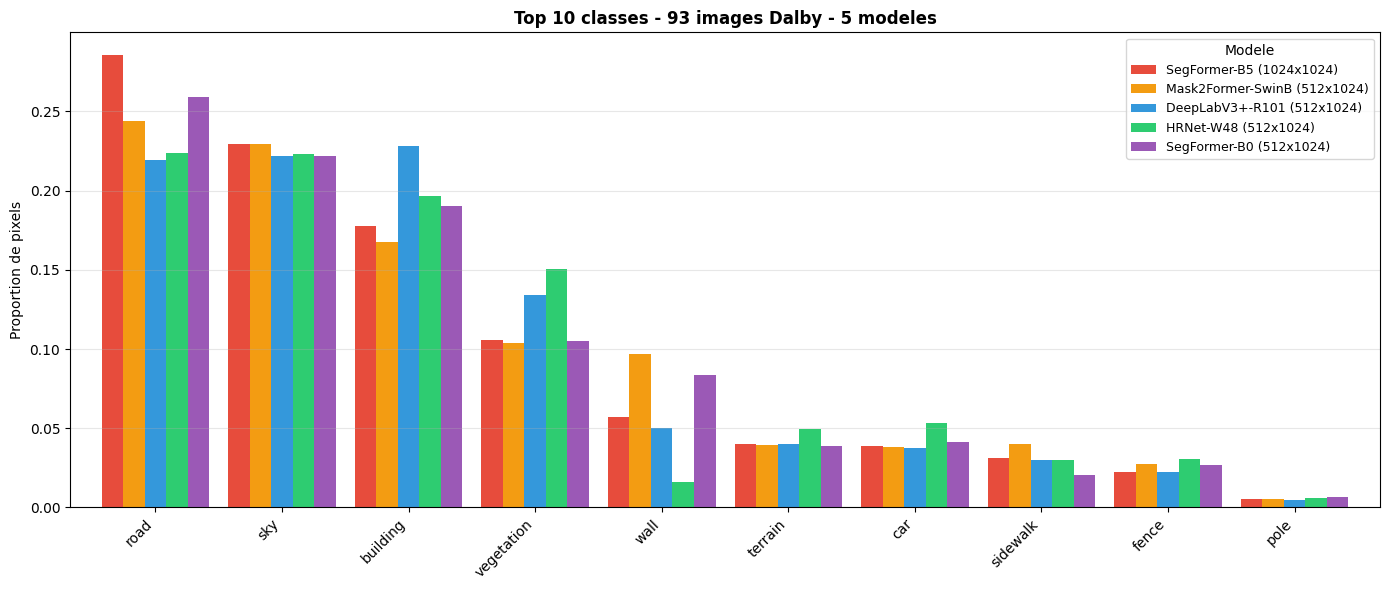

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))
top_classes = distrib_df.head(10)
colors = ["#e74c3c", "#f39c12", "#3498db", "#2ecc71", "#9b59b6"][:len(distrib_df.columns)]
top_classes.plot(kind="bar", ax=ax, width=0.85, color=colors)
ax.set_ylabel("Proportion de pixels")
ax.set_title(f"Top 10 classes - {len(image_files)} images Dalby - 5 modeles",
             fontweight="bold", fontsize=12)
ax.legend(title="Modele", loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Matrice d'accord pixel-à-pixel (la figure clé)

3 zones d'intérêt à observer dans la matrice 5×5 :
- **B5 ↔ B0** : effet de la capacité du backbone (architecture identique)
- **B0 ↔ Mask2Former, B0 ↔ DeepLabV3+, B0 ↔ HRNet-W48** : effet de l'architecture (à crop égal)
- **B5 ↔ Mask2Former** : champion vs champion
- **HRNet-W48 ↔ DeepLabV3+** : deux encodeurs convolutifs plein résolution

In [ ]:
def pixel_agreement(masks_a, masks_b, classes_of_interest=(0, 2, 8, 10)):
    """Calcule l'accord moyen sur les classes route, batiment, vegetation, ciel."""
    agreements = []
    for img_name in masks_a.keys():
        if img_name not in masks_b:
            continue
        m_a = masks_a[img_name]
        m_b = masks_b[img_name]
        mask_classes = np.isin(m_a, classes_of_interest) | np.isin(m_b, classes_of_interest)
        if mask_classes.sum() == 0:
            continue
        agreements.append((m_a[mask_classes] == m_b[mask_classes]).mean())
    return np.mean(agreements) if agreements else 0


# Construction matrice
model_names = list(all_masks.keys())
n = len(model_names)
agreement_matrix = np.zeros((n, n))
for i, name_a in enumerate(model_names):
    for j, name_b in enumerate(model_names):
        agreement_matrix[i, j] = pixel_agreement(all_masks[name_a], all_masks[name_b])

# Affichage avec annotations
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(agreement_matrix, cmap="RdYlGn", vmin=0.5, vmax=1.0)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{agreement_matrix[i, j]:.3f}",
                ha="center", va="center",
                color="black" if agreement_matrix[i, j] > 0.7 else "white",
                fontsize=12, fontweight="bold")

# Labels courts
short_labels = [name.split(" (")[0] for name in model_names]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(short_labels, fontsize=10)
ax.set_title("Accord pixel-a-pixel entre les 4 modeles\n(classes route/batiment/vegetation/ciel)",
             fontweight="bold", fontsize=12, pad=15)
plt.colorbar(im, ax=ax, label="Proportion d'accord")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "agreement_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

agreement_df = pd.DataFrame(agreement_matrix, index=short_labels, columns=short_labels)
agreement_df.to_csv(OUTPUT_DIR / "agreement_matrix.csv")

## 10. Analyses comparatives ciblées

### Analyse A — Effet du backbone SegFormer (B5 vs B0)
### Analyse B — Architecture à crop égal (B0 vs Mask2Former vs DeepLabV3+ vs HRNet-W48)
### Analyse C — Champion vs Champion (B5 vs Mask2Former)
### Analyse D — HRNet-W48 vs autres architectures convolutives

In [29]:
# Extraction des accords pertinents
b5_name = [n for n in model_names if "SegFormer-B5" in n][0]
b0_name = [n for n in model_names if "SegFormer-B0" in n][0]
m2f_name = [n for n in model_names if "Mask2Former" in n][0]
dlb_name = [n for n in model_names if "DeepLabV3+" in n][0]
hrnet_name = [n for n in model_names if "HRNet-W48" in n][0]

# Indices
def idx(name):
    return model_names.index(name)

print("=" * 65)
print("  ANALYSES COMPARATIVES CIBLEES")
print("=" * 65)

print("\n[A] Effet du backbone SegFormer (memes architecture)")
print(f"    B5 vs B0  : accord = {agreement_matrix[idx(b5_name), idx(b0_name)]:.3f}")
print(f"    Crop      : 1024x1024 vs 512x1024")
print(f"    Params    : 84.7M vs 3.8M  (rapport ~22x)")

print("\n[B] Architecture a crop egal (512x1024)")
print(f"    B0 vs Mask2Former        : accord = {agreement_matrix[idx(b0_name), idx(m2f_name)]:.3f}")
print(f"    B0 vs DeepLabV3+         : accord = {agreement_matrix[idx(b0_name), idx(dlb_name)]:.3f}")
print(f"    Mask2Former vs DeepLabV3+: accord = {agreement_matrix[idx(m2f_name), idx(dlb_name)]:.3f}")

print("\n[C] Champion vs champion (config optimale de chaque)")
print(f"    B5 (1024x1024) vs Mask2Former (512x1024) : accord = {agreement_matrix[idx(b5_name), idx(m2f_name)]:.3f}")
print(f"    B5 (1024x1024) vs DeepLabV3+ (512x1024)  : accord = {agreement_matrix[idx(b5_name), idx(dlb_name)]:.3f}")

print("\n[D] HRNet-W48 vs autres architectures convolutives (512x1024)")
print(f"    HRNet-W48 vs DeepLabV3+    : accord = {agreement_matrix[idx(hrnet_name), idx(dlb_name)]:.3f}")
print(f"    HRNet-W48 vs Mask2Former   : accord = {agreement_matrix[idx(hrnet_name), idx(m2f_name)]:.3f}")
print(f"    HRNet-W48 vs SegFormer-B0  : accord = {agreement_matrix[idx(hrnet_name), idx(b0_name)]:.3f}")

  ANALYSES COMPARATIVES CIBLEES

[A] Effet du backbone SegFormer (memes architecture)
    B5 vs B0  : accord = 0.856
    Crop      : 1024x1024 vs 512x1024
    Params    : 84.7M vs 3.8M  (rapport ~22x)

[B] Architecture a crop egal (512x1024)
    B0 vs Mask2Former        : accord = 0.842
    B0 vs DeepLabV3+         : accord = 0.802
    Mask2Former vs DeepLabV3+: accord = 0.796

[C] Champion vs champion (config optimale de chaque)
    B5 (1024x1024) vs Mask2Former (512x1024) : accord = 0.863
    B5 (1024x1024) vs DeepLabV3+ (512x1024)  : accord = 0.812


## 11. Visualisations comparatives (5 images)

In [29]:
def disagreement_score(image_name):
    sky_props = []
    for name in all_masks.keys():
        if image_name in all_masks[name]:
            mask = all_masks[name][image_name]
            sky_props.append((mask == 10).sum() / mask.size)
    return np.std(sky_props) if len(sky_props) >= 2 else 0


scores = [(img.name, disagreement_score(img.name)) for img in image_files]
scores.sort(key=lambda x: x[1], reverse=True)
selected = [s[0] for s in scores[:90]]

print(f"5 images les plus contestees :")
for s in selected:
    print(f"  - {s}")

5 images les plus contestees :
  - dalby_318439379850672.jpg
  - dalby_2414914741985942.jpg
  - dalby_162266702507179.jpg
  - dalby_477354603319812.jpg
  - dalby_2633961840229521.jpg
  - dalby_209386617474167.jpg
  - dalby_948085442648991.jpg
  - dalby_127424319410979.jpg
  - dalby_165646615564502.jpg
  - dalby_207117067726610.jpg
  - dalby_336945947850172.jpg
  - dalby_307819134278568.jpg
  - dalby_217532203253906.jpg
  - dalby_3058379274486013.jpg
  - dalby_1072637699813412.jpg
  - dalby_191060486200658.jpg
  - dalby_797662007526230.jpg
  - dalby_176477167721936.jpg
  - dalby_247499187168469.jpg
  - dalby_296849652169327.jpg
  - dalby_184023580256808.jpg
  - dalby_1847770912060630.jpg
  - dalby_2399280866908296.jpg
  - dalby_160428449352367.jpg
  - dalby_1129558857532769.jpg
  - dalby_293942942366778.jpg
  - dalby_304811034578258.jpg
  - dalby_1411605992538138.jpg
  - dalby_505651603901769.jpg
  - dalby_1126405431179905.jpg
  - dalby_1106794199827157.jpg
  - dalby_190529462942666.jpg

In [ ]:
SAMPLES_DIR = OUTPUT_DIR / "comparisons"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

for img_name in selected:
    img_path = PERSP_DIR / img_name
    image = Image.open(img_path).convert("RGB")

    n_models = len(all_masks)
    fig, axes = plt.subplots(1, 1 + n_models, figsize=(7 * (1 + n_models), 6))
    axes[0].imshow(image)
    axes[0].set_title("Image originale", fontweight="bold", fontsize=13)
    axes[0].axis("off")

    for ax, model_name in zip(axes[1:], all_masks.keys()):
        mask = all_masks[model_name][img_name]
        ax.imshow(overlay(image, mask))
        ax.set_title(model_name, fontweight="bold", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    out_path = SAMPLES_DIR / f"comparison_{img_path.stem}.png"
    plt.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\n{len(selected)} comparaisons dans {SAMPLES_DIR}")

## 12. Graphique FPS coloré par crop

In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 5))
summary_reset = summary.reset_index().sort_values("fps_mean", ascending=True)

crop_colors = {"1024x1024": "#3498db", "512x1024": "#e74c3c"}
colors = [crop_colors[c] for c in summary_reset["crop"]]

ax.barh(summary_reset["model"], summary_reset["fps_mean"], color=colors,
        xerr=summary_reset["time_std_ms"] / summary_reset["time_mean_ms"] * summary_reset["fps_mean"])
ax.set_xlabel("FPS (image/seconde)")
ax.set_title(f"Vitesse d'inference - 5 modeles - RTX 2060 - {len(image_files)} images Dalby",
             fontweight="bold")
ax.grid(axis="x", alpha=0.3)

legend = [Patch(color=c, label=f"Crop {k}") for k, c in crop_colors.items()]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fps_comparison.png", dpi=110, bbox_inches="tight")
plt.show()